#  XGBoost Model — Economic Expenditure Predictor

This notebook predicts **6 government spending sectors** (as % of GDP) using XGBoost.


In [3]:
print('Hello')

Hello


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Import Libraries
# ─────────────────────────────────────────────────────────────────────────────
# These are the tools we need:
#   pandas   → for loading and working with our data table
#   numpy    → for math operations
#   matplotlib / seaborn → for drawing charts
#   sklearn  → helper tools: encoding, splitting data, measuring accuracy
#   xgboost  → the main model we're building!

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')   # hides harmless warning messages

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor   # lets XGBoost predict 6 targets at once
from sklearn.model_selection import GridSearchCV
import xgboost as xgb   #  our main model!

print(" All libraries imported successfully!")
print(f"   XGBoost version: {xgb.__version__}")

 All libraries imported successfully!
   XGBoost version: 3.2.0


---
##  Step 1 — Load the Dataset

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Load Data
# ─────────────────────────────────────────────────────────────────────────────
# We read the CSV file into a DataFrame (think of it as an Excel table in Python)

df = pd.read_csv("refined_economic_dataset.csv")

print(f"\n   Dataset loaded successfully!")
print(f"     Rows    : {df.shape[0]}")
print(f"     Columns : {df.shape[1]}")

print("\n  Dataset Info :")
print(f"    Countries  : {sorted(df['country_name'].unique())}")
print(f"    Year Range : {df['year'].min()} → {df['year'].max()}")
print(f"    Missing Values :\n{df.isnull().sum()}")
print(f"\n  Statistical Summary :\n{df.describe().round(2)}")


  ✅ Dataset loaded successfully!
     Rows    : 345
     Columns : 10

  Dataset Info :
    Countries  : ['Bangladesh', 'China', 'India', 'Indonesia', 'Kazakhstan', 'Korea, Rep.', 'Malaysia', 'Philippines', 'Saudi Arabia', 'Singapore', 'Sri Lanka', 'Thailand', 'Turkiye', 'United Arab Emirates', 'Viet Nam']
    Year Range : 2001 → 2023
    Missing Values :
country_name             0
year                     0
health_expense           0
total_gov_expense        0
education_expense        0
capital_formation_exp    0
military_expense         0
r&d_expense              0
total_gdp                0
log_gdp                  0
dtype: int64

  Statistical Summary :
          year  health_expense  total_gov_expense  education_expense  \
count   345.00          345.00             345.00             345.00   
mean   2012.00            3.92              16.95               3.60   
std       6.64            1.14               6.38               1.18   
min    2001.00            1.77               

---
##  Step 2 — Define Targets & Features

- **Targets (Y)** — what we want the model to *predict* (6 spending sectors)
- **Features (X)** — the inputs the model *uses* to make predictions

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Define Columns
# ─────────────────────────────────────────────────────────────────────────────

# These are the 6 things we want to predict (all measured as % of GDP)
TARGET_COLS = [
    "health_expense",
    "total_gov_expense",
    "education_expense",
    "capital_formation_exp",
    "military_expense",
    "r&d_expense"
]

# Chart colors — one per sector
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

print(f"  Targets defined : {TARGET_COLS}")

  Targets defined : ['health_expense', 'total_gov_expense', 'education_expense', 'capital_formation_exp', 'military_expense', 'r&d_expense']


---
##  Step 3 — Prepare Features

Machine learning models only understand **numbers** — not text like `"India"`.  
So we convert country names into numeric codes using **LabelEncoder**.

We also apply `log10` to GDP because GDP values span trillions — the log scale compresses them into a smaller, friendlier range for the model.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Encode & Engineer Features
# ─────────────────────────────────────────────────────────────────────────────

# Step A: Convert country names to numbers
# e.g. "Bangladesh" → 0, "China" → 1, "India" → 2 ...
le = LabelEncoder()
df["country_encoded"] = le.fit_transform(df["country_name"])

# Save the mapping so we can look up codes later (needed in predict function)
country_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"\n  Country Encoding Map :")
for k, v in country_mapping.items():
    print(f"    {v:2d} → {k}")

# Step B: Log-transform GDP
# GDP like 3,500,000,000,000 becomes a manageable 12.54
df["log_gdp"] = np.log10(df["total_gdp"])

# Step C: Select the 3 features we'll feed into the model
FEATURE_COLS = ["country_encoded", "year", "log_gdp"]

X = df[FEATURE_COLS]   # inputs
Y = df[TARGET_COLS]    # outputs

print(f"\n  Feature matrix X shape : {X.shape}   ← ({X.shape[0]} rows × {X.shape[1]} features)")
print(f"  Target matrix  Y shape : {Y.shape}   ← ({Y.shape[0]} rows × {Y.shape[1]} targets)")
print(f"\n   Features used : {FEATURE_COLS}")
print(f"   Targets       : {TARGET_COLS}")


  Country Encoding Map :
     0 → Bangladesh
     1 → China
     2 → India
     3 → Indonesia
     4 → Kazakhstan
     5 → Korea, Rep.
     6 → Malaysia
     7 → Philippines
     8 → Saudi Arabia
     9 → Singapore
    10 → Sri Lanka
    11 → Thailand
    12 → Turkiye
    13 → United Arab Emirates
    14 → Viet Nam

  Feature matrix X shape : (345, 3)   ← (345 rows × 3 features)
  Target matrix  Y shape : (345, 6)   ← (345 rows × 6 targets)

   Features used : ['country_encoded', 'year', 'log_gdp']
   Targets       : ['health_expense', 'total_gov_expense', 'education_expense', 'capital_formation_exp', 'military_expense', 'r&d_expense']


---
##  Step 4 — Split into Train & Test Sets

We split the data so the model learns on 80% and is tested on the remaining 20% it has **never seen**.  
This tells us how well it generalises to new data.

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Train / Test Split
# ─────────────────────────────────────────────────────────────────────────────

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.20,    # 20% goes to testing
    random_state=42    # fixed seed → same split every run (reproducible)
)

print(f"    Split complete!")
print(f"   Training samples : {X_train.shape[0]}  (80%)")
print(f"   Testing  samples : {X_test.shape[0]}   (20%)")

   ✅ Split complete!
   Training samples : 276  (80%)
   Testing  samples : 69   (20%)


---
##  Step 5 — Build & Train the XGBoost Model

### Key Hyperparameters explained:

| Parameter | What it does | Our value |
|---|---|---|
| `n_estimators` | How many boosting rounds (trees) to build | 300 |
| `max_depth` | How deep each tree can go | 5 |
| `learning_rate` | How much each tree corrects the previous mistake | 0.05 |
| `subsample` | Fraction of rows used per tree (prevents overfitting) | 0.8 |
| `colsample_bytree` | Fraction of features used per tree | 0.8 |
| `reg_alpha` | L1 regularisation — pushes small weights to zero | 0.1 |
| `reg_lambda` | L2 regularisation — keeps weights small overall | 1.0 |



In [9]:
# # ─────────────────────────────────────────────────────────────────────────────
# # CELL 6 — Build & Train XGBoost
# # ─────────────────────────────────────────────────────────────────────────────
# # XGBoost's built-in regressor only predicts ONE target at a time.
# # To predict all 6 sectors simultaneously, we wrap it in MultiOutputRegressor.
# # (Random Forest didn't need this wrapper — XGBoost does.)

# base_xgb = xgb.XGBRegressor(
#     n_estimators    = 300,      # number of trees
#     max_depth       = 5,        # tree depth  (3–6 is usually good)
#     learning_rate   = 0.05,     # also called 'eta' — step size for correction
#     subsample       = 0.8,      # 80% of data rows used per tree
#     colsample_bytree= 0.8,      # 80% of features used per tree
#     reg_alpha       = 0.1,      # L1 regularisation (reduces overfitting)
#     reg_lambda      = 1.0,      # L2 regularisation (reduces overfitting)
#     objective       = 'reg:squarederror',   # standard regression loss
#     random_state    = 42,       # reproducibility
#     n_jobs          = -1        # use all CPU cores
# )

# # Wrap to handle 6 outputs at once
# model = MultiOutputRegressor(base_xgb, n_jobs=-1)

# print("   Training XGBoost model ... (this may take ~10-30 seconds)")
# model.fit(X_train, Y_train)

# Y_pred_test  = model.predict(X_test)
# Y_pred_train = model.predict(X_train)
# #
# print("   Training complete!")
# print(f"     Prediction shape : {Y_pred_test.shape}  ← (rows × 6 sectors)")

  ⏳ Training XGBoost model ... (this may take ~10-30 seconds)
  ✅ Training complete!
     Prediction shape : (69, 6)  ← (rows × 6 sectors)


In [26]:



base_xgb = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)


multi_model = MultiOutputRegressor(base_xgb)

param_grid = {
    'estimator__n_estimators': [500, 1000],
    'estimator__max_depth': [2, 3, 4],           
    'estimator__learning_rate': [0.01, 0.05],   
    'estimator__reg_alpha': [1, 5, 10],          
    'estimator__subsample': [0.6, 0.7]           
}

grid_search = GridSearchCV(
    estimator=multi_model,
    param_grid=param_grid,
    cv=3, 
    scoring='r2', 
    verbose=1, 
    n_jobs=-1
)

print("Searching for the best parameters... (This may take a minute)")
grid_search.fit(X_train, Y_train)


best_model = grid_search.best_estimator_

print("\nBest Parameters found:")
print(grid_search.best_params_)


Y_pred_test  = best_model.predict(X_test)
Y_pred_train = best_model.predict(X_train)

print(f"\nTraining complete with best parameters!")
print(f"Prediction shape: {Y_pred_test.shape}")

Searching for the best parameters... (This may take a minute)
Fitting 3 folds for each of 72 candidates, totalling 216 fits

Best Parameters found:
{'estimator__learning_rate': 0.05, 'estimator__max_depth': 4, 'estimator__n_estimators': 1000, 'estimator__reg_alpha': 1, 'estimator__subsample': 0.7}

Training complete with best parameters!
Prediction shape: (69, 6)


---
##  Step 6 — Evaluate the Model

We measure accuracy using three metrics:

| Metric | Meaning | Better when... |
|---|---|---|
| **R²** | % of variation explained by the model (0 to 1) | Closer to **1** |
| **MAE** | Average prediction error (same unit as target) | **Lower** |
| **RMSE** | Like MAE but penalises big errors more heavily | **Lower** |

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Metrics Table
# ─────────────────────────────────────────────────────────────────────────────

results = []
for i, col in enumerate(TARGET_COLS):
    r2_train = r2_score(Y_train.iloc[:, i], Y_pred_train[:, i])
    r2_test  = r2_score(Y_test.iloc[:, i],  Y_pred_test[:, i])
    mae      = mean_absolute_error(Y_test.iloc[:, i], Y_pred_test[:, i])
    rmse     = np.sqrt(mean_squared_error(Y_test.iloc[:, i], Y_pred_test[:, i]))

    results.append({
        "Sector"  : col,
        "R² Train": round(r2_train, 4),
        "R² Test" : round(r2_test,  4),
        "MAE"     : round(mae,  4),
        "RMSE"    : round(rmse, 4)
    })

results_df = pd.DataFrame(results)
print("\n  Evaluation Metrics per Sector :\n")
print(results_df.to_string(index=False))
print("\n   R² Test close to 1.0 = great predictions!")
print("     A large gap between R² Train and R² Test = overfitting (model memorised training data).")


  Evaluation Metrics per Sector :

               Sector  R² Train  R² Test    MAE   RMSE
       health_expense    0.9825   0.8652 0.2890 0.4068
    total_gov_expense    0.9981   0.9436 0.9025 1.2611
    education_expense    0.9840   0.8389 0.2762 0.4015
capital_formation_exp    0.9962   0.8470 1.7437 2.4046
     military_expense    0.9951   0.9287 0.2839 0.5757
          r&d_expense    0.9903   0.9546 0.1289 0.1956

   R² Test close to 1.0 = great predictions!
     A large gap between R² Train and R² Test = overfitting (model memorised training data).


---
##  Step 7 — Visualise the Results

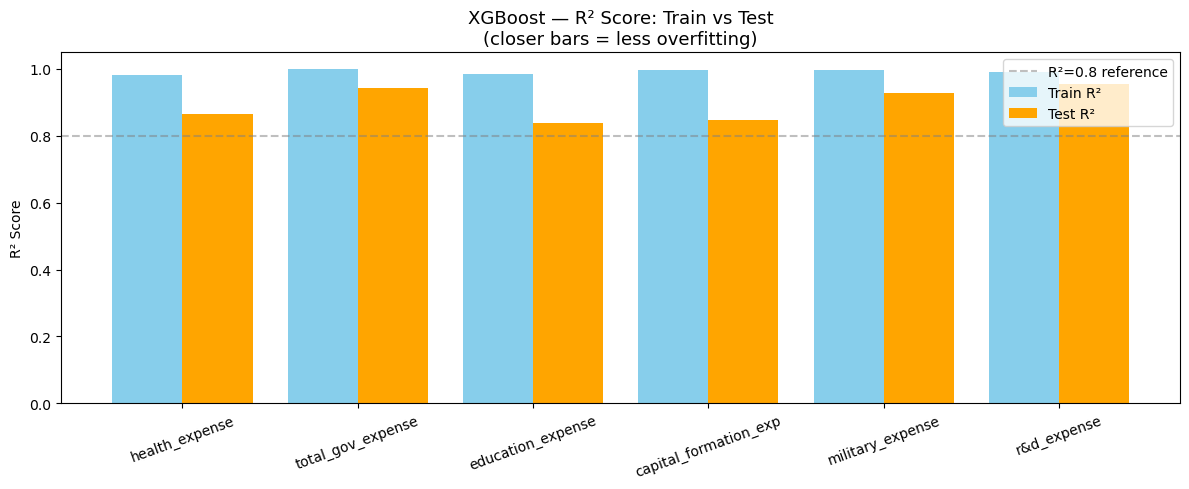

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — R² Score Chart: Train vs Test
# ─────────────────────────────────────────────────────────────────────────────
# If the orange (Test) bar is much shorter than the blue (Train) bar,
# it signals overfitting — the model is too tuned to the training data.

plt.figure(figsize=(12, 5))
x = np.arange(len(TARGET_COLS))

plt.bar(x - 0.2, results_df["R² Train"], width=0.4, label="Train R²", color="skyblue")
plt.bar(x + 0.2, results_df["R² Test"],  width=0.4, label="Test R²",  color="orange")

plt.xticks(x, TARGET_COLS, rotation=20)
plt.ylabel("R² Score")
plt.ylim(0, 1.05)
plt.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='R²=0.8 reference')
plt.title("XGBoost — R² Score: Train vs Test\n(closer bars = less overfitting)", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

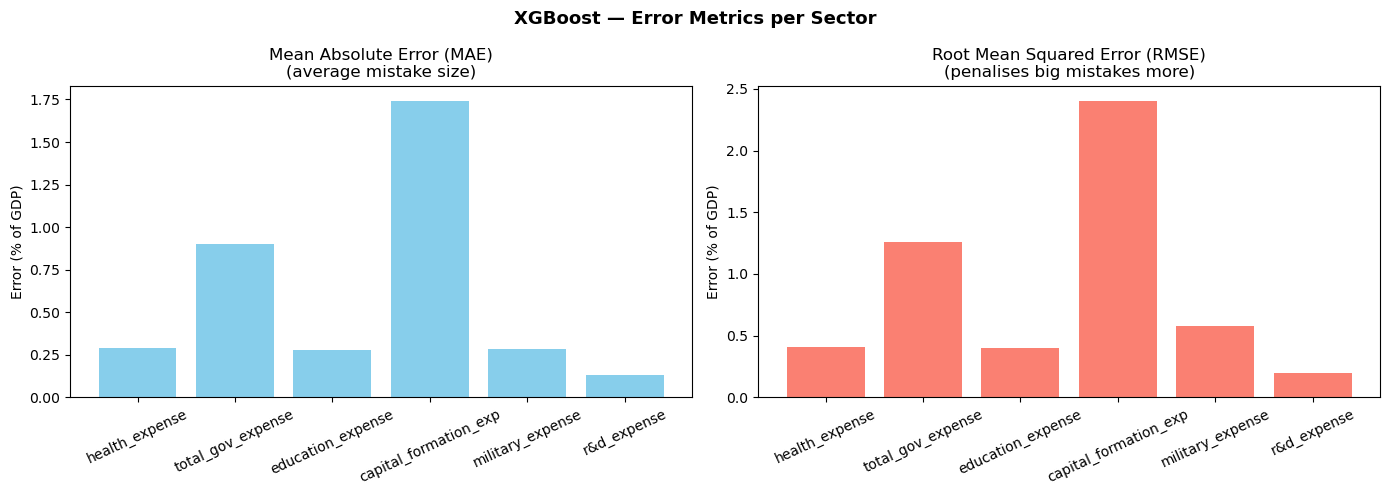

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — MAE & RMSE Charts
# ─────────────────────────────────────────────────────────────────────────────
# These bars show the average error in % of GDP units.
# Shorter bars = more accurate predictions.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(TARGET_COLS, results_df["MAE"],  color='skyblue')
axes[0].set_title("Mean Absolute Error (MAE)\n(average mistake size)")
axes[0].set_ylabel("Error (% of GDP)")
axes[0].tick_params(axis='x', rotation=25)

axes[1].bar(TARGET_COLS, results_df["RMSE"], color='salmon')
axes[1].set_title("Root Mean Squared Error (RMSE)\n(penalises big mistakes more)")
axes[1].set_ylabel("Error (% of GDP)")
axes[1].tick_params(axis='x', rotation=25)

plt.suptitle("XGBoost — Error Metrics per Sector", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

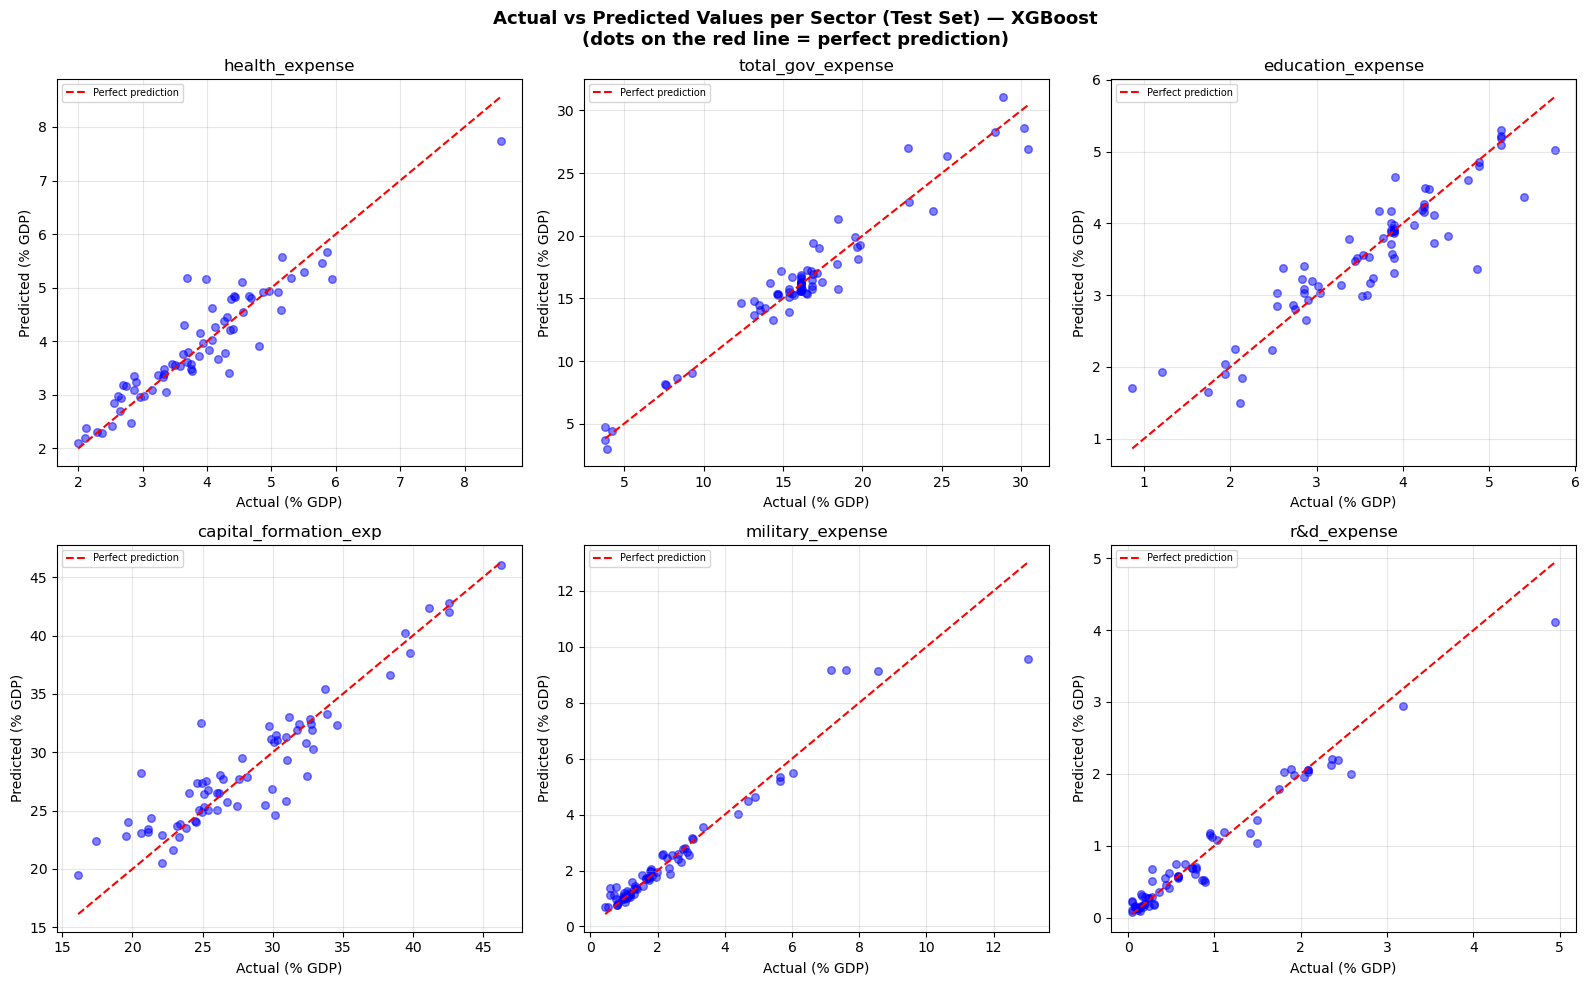

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Actual vs Predicted Scatter Plots
# ─────────────────────────────────────────────────────────────────────────────
# Each dot = one country-year sample.
# The red dashed line = perfect prediction (actual == predicted).
# Dots hugging the line closely = good model!

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Actual vs Predicted Values per Sector (Test Set) — XGBoost\n"
             "(dots on the red line = perfect prediction)",
             fontsize=13, fontweight="bold")

for i, col in enumerate(TARGET_COLS):
    plt.subplot(2, 3, i + 1)
    actual    = Y_test.iloc[:, i]
    predicted = Y_pred_test[:, i]

    plt.scatter(actual, predicted, color='blue', alpha=0.5, s=30)
    plt.plot([actual.min(), actual.max()],
             [actual.min(), actual.max()],
             'r--', label='Perfect prediction')

    plt.title(col)
    plt.xlabel("Actual (% GDP)")
    plt.ylabel("Predicted (% GDP)")
    plt.legend(fontsize=7)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
##  Step 8 — Feature Importance

XGBoost tells us **which features mattered most** for each sector's prediction.  
A higher importance score = that feature had more influence on the output.

In [14]:
# # ─────────────────────────────────────────────────────────────────────────────
# # CELL 11 — Feature Importance per Sector
# # ─────────────────────────────────────────────────────────────────────────────
# # model.estimators_ holds one XGBRegressor per target.
# # We extract the importances from each and plot them side by side.

# fig, axes = plt.subplots(2, 3, figsize=(16, 9))
# fig.suptitle("XGBoost — Feature Importance per Sector\n"
#              "(which input influenced each prediction the most?)",
#              fontsize=13, fontweight="bold")

# for i, (col, ax) in enumerate(zip(TARGET_COLS, axes.flatten())):
#     importances = model.estimators_[i].feature_importances_
#     imp_df = pd.DataFrame({
#         "Feature"   : FEATURE_COLS,
#         "Importance": importances
#     }).sort_values("Importance", ascending=True)

#     ax.barh(imp_df["Feature"], imp_df["Importance"], color=colors[i])
#     ax.set_title(col)
#     ax.set_xlabel("Importance Score")
#     ax.grid(axis='x', alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Also print average importance across all 6 sectors
# avg_imp = np.mean([model.estimators_[i].feature_importances_
#                    for i in range(len(TARGET_COLS))], axis=0)
# print("\n  Average Feature Importance across all sectors:")
# for feat, imp in sorted(zip(FEATURE_COLS, avg_imp), key=lambda x: -x[1]):
#     print(f"    {feat:20s} : {imp:.4f}")

---
##  Step 9 — Predict for Any Country

Now the fun part! Given a country, year, and GDP, predict all 6 spending sectors.

In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — Predict Expenditure Function
# ─────────────────────────────────────────────────────────────────────────────

VALID_COUNTRIES = sorted(df["country_name"].unique())

def predict_expenditure(country_name: str,
                        year: int,
                        total_gdp: float) -> pd.DataFrame:
    """
    Predict sector expenditures for a given country, year, and GDP.

    Parameters
    ----------
    country_name : str   — e.g. "India"
    year         : int   — e.g. 2025
    total_gdp    : float — in USD, e.g. 3_500_000_000_000

    Returns
    -------
    DataFrame with predicted % of GDP and estimated USD for each sector.
    """
    # ── Validate inputs ──────────────────────────────────────
    if country_name not in VALID_COUNTRIES:
        suggestions = [c for c in VALID_COUNTRIES
                       if country_name.lower() in c.lower()]
        msg = f"'{country_name}' not found.\n   Available: {VALID_COUNTRIES}"
        if suggestions:
            msg = f"'{country_name}' not found. Did you mean: {suggestions}?\n   Available: {VALID_COUNTRIES}"
        raise ValueError(msg)

    if not (2000 <= year <= 2100):
        raise ValueError(f"Year {year} seems unrealistic. Use a 4-digit year.")

    if total_gdp <= 0:
        raise ValueError("GDP must be a positive number.")

    # ── Prepare input in the same format as training data ────
    country_encoded = country_mapping[country_name]
    log_gdp         = np.log10(total_gdp)

    input_df = pd.DataFrame({
        "country_encoded": [country_encoded],
        "year"           : [year],
        "log_gdp"        : [log_gdp]
    })

    # ── Run prediction ───────────────────────────────────────
    pred_array = model.predict(input_df)[0]   # gives us an array of 6 values

    # ── Format nicely ────────────────────────────────────────
    output = pd.DataFrame({
        "Sector"             : [c.replace("_", " ").title() for c in TARGET_COLS],
        "Predicted % of GDP" : np.round(pred_array, 4),
        "Estimated USD"      : np.round(pred_array / 100 * total_gdp, 2)
    })

    return output


# ── Quick test ───────────────────────────────────────────────────────────────
print("  Quick test — India, 2022, GDP = 3.39 trillion USD")
print(predict_expenditure("India", 2022, 3_390_000_000_000))

  Quick test — India, 2022, GDP = 3.39 trillion USD
                  Sector  Predicted % of GDP  Estimated USD
0         Health Expense              3.4464   1.168334e+11
1      Total Gov Expense             13.6194   4.616962e+11
2      Education Expense              4.1924   1.421235e+11
3  Capital Formation Exp             33.2878   1.128455e+12
4       Military Expense              2.3832   8.079212e+10
5            R&D Expense              0.6640   2.250837e+10


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 — Interactive Predictor with Chart
# ─────────────────────────────────────────────────────────────────────────────
# If year is within the dataset range → shows Actual vs Predicted bars.
# If year is beyond the dataset      → shows Last Known Year vs Predicted bars.

def predict_and_show(country, year, gdp):

    # ── Input check ──────────────────────────────────────────
    if country not in VALID_COUNTRIES:
        print(f"❌ '{country}' doesn't exist in the dataset.")
        print(f"   Available: {VALID_COUNTRIES}")
        return

    # ── Look for actual historical data ──────────────────────
    actual_exists = False
    last_year_percentages = None

    if year <= 2023:
        past_data = df[(df['country_name'] == country) & (df['year'] == year)]
        if not past_data.empty:
            actual_exists      = True
            actual_percentages = past_data[TARGET_COLS].values[0]
    else:
        # For future years, we show the most recent actual year as a reference
        past_data = df[(df['country_name'] == country) &
                       (df['year'] == df['year'].max())]
        if not past_data.empty:
            last_year_percentages = past_data[TARGET_COLS].values[0]

    # ── Build input for prediction ───────────────────────────
    input_df = pd.DataFrame({
        "country_encoded": [country_mapping[country]],
        "year"           : [year],
        "log_gdp"        : [np.log10(gdp)]
    })

    pred_percentages = model.predict(input_df)[0]
    billion_usd      = (pred_percentages / 100 * gdp) / 1_000_000_000

    # ── Build results table ───────────────────────────────────
    if actual_exists:
        results = pd.DataFrame({
            "Sector"                 : TARGET_COLS,
            "Actual (%)"             : np.round(actual_percentages, 2),
            "Predicted (%)"          : np.round(pred_percentages, 2),
            "Predicted (Billion USD)": np.round(billion_usd, 2)
        })
    else:
        ref = last_year_percentages if last_year_percentages is not None else [np.nan]*6
        results = pd.DataFrame({
            "Sector"                 : TARGET_COLS,
            "Last Known (%)"         : np.round(ref, 2),
            "Predicted (%)"          : np.round(pred_percentages, 2),
            "Predicted (Billion USD)": np.round(billion_usd, 2)
        })

    print(f"\n  📊 Result: {country} ({year})")
    print("-" * 55)
    print(results.to_string(index=False))

    # ── Bar Chart ─────────────────────────────────────────────
    plt.figure(figsize=(10, 5))
    x     = np.arange(len(TARGET_COLS))
    width = 0.35

    if actual_exists:
        plt.bar(x - width/2, actual_percentages,      width=width, label='Actual Data',    color='salmon')
        plt.bar(x + width/2, results["Predicted (%)"], width=width, label='Predicted Data', color='skyblue')
        plt.title(f"XGBoost — Actual vs Predicted Expenditure\n{country} ({year})", fontsize=12)
    else:
        ref_vals = last_year_percentages if last_year_percentages is not None else [0]*6
        plt.bar(x - width/2, ref_vals,                width=width, label=f'Last Known Data', color='salmon')
        plt.bar(x + width/2, results["Predicted (%)"], width=width, label='Predicted Data',   color='skyblue')
        plt.title(f"XGBoost — Last Known vs Predicted Expenditure\n{country} ({year})", fontsize=12)

    plt.xticks(x, TARGET_COLS, rotation=15)
    plt.ylabel("% of GDP")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# CELL 14 — Interactive Loop
# ─────────────────────────────────────────────────────────────────────────────
print("\n Welcome to the XGBoost Budget Predictor!")
print("   Type 'quit' at any time to exit.\n")

while True:
    print("=" * 55)
    print("  Available countries:", df['country_name'].unique().tolist())

    user_country = input("\n  Enter Country Name : ").strip()

    if user_country.lower() == "quit":
        print("   Goodbye!")
        break

    try:
        user_year = int(input("  Enter Year         : "))

        # Try to show the actual GDP from the dataset as a hint
        if 2000 < user_year < 2024 and user_country in VALID_COUNTRIES:
            row = df[(df['country_name'] == user_country) &
                     (df['year'] == user_year)].reset_index(drop=True)
            if not row.empty:
                hint = f"  (Dataset GDP for this year: {row['total_gdp'].values[0]:,.0f})"
            else:
                hint = ""
        else:
            max_gdp = df[df['country_name'] == user_country]['total_gdp'].max() if user_country in VALID_COUNTRIES else "?"
            min_gdp = df[df['country_name'] == user_country]['total_gdp'].min() if user_country in VALID_COUNTRIES else "?"
            hint    = f"  (Historical range: {min_gdp:,.0f} – {max_gdp:,.0f})"

        print(hint)
        user_gdp = float(input("  Enter Total GDP (USD): "))

        predict_and_show(user_country, user_year, user_gdp)

    except ValueError as e:
        print(f"    Error: {e}")
    except Exception as e:
        print(f"   Unexpected error: {e}")


 Welcome to the XGBoost Budget Predictor!
   Type 'quit' at any time to exit.

  Available countries: ['Bangladesh', 'China', 'India', 'Indonesia', 'Kazakhstan', 'Korea, Rep.', 'Malaysia', 'Philippines', 'Saudi Arabia', 'Singapore', 'Sri Lanka', 'Thailand', 'Turkiye', 'United Arab Emirates', 'Viet Nam']



  Enter Country Name :  quit


   Goodbye!
